# G1 Fato ou Fake: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "g1_fato_ou_fake"
PLAYER = "G1 Fato ou Fake"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,g1_fato_ou_fake,g1_fato_ou_fake,G1 Fato ou Fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, direct_fake_fato_mapping",


SpiderProfile(spider='g1_fato_ou_fake', display_name='G1 Fato ou Fake', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'direct_fake_fato_mapping'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
18,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,3412,27,3385,0,True,True
2,20260304T060438Z-06309984,2026-03-04 06:04:39+00:00,2026-03-04 06:16:14+00:00,3387,3387,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,G1 Fato ou Fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,27,27,0,2025-10-27 11:01:16.026000+00:00,2026-03-14 19:29:37.911000+00:00,0,0


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,c4f7de842ae80416592fb72f04611160784fe3c1efc3071bc4de3d2a74f77aee,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-que-video-mostre-barragem-de-santa-branca-no-interior-de-sp-se-rompendo-reservatorio-esta-bem-ab...,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-que-video-mostre-barragem-de-santa-branca-no-interior-de-sp-se-rompendo-reservatorio-esta-bem-ab...,"É #FAKE que vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite",2025-10-27T08:01:17.412-03:00,2026-03-15T02:50:32+00:00,"vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite","As imagens não representam um evento real; elas foram fabricadas com uso de inteligência artificial. A Light Energia, responsável pela gestão da barragem, a...",FAKE,FAKE,pt-BR,BR,"[G1, Fato ou Fake]",[],[],NewsArticle,20260315T010005Z-1d265f16,2025-10-27 11:01:17.412000+00:00,2026-03-15 02:50:32+00:00,3327.820719,121,109,265,g1.globo.com,1.0
1,d88581fc9b6d8b3463cdb72679954664d3b6da52f8019ab53e9ef5f85cd855ea,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-video-que-mostra-mulher-com-sapatos-voadores-em-exposicao.ghtml,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-video-que-mostra-mulher-com-sapatos-voadores-em-exposicao.ghtml,É #FAKE vídeo que mostra mulher com sapatos voadores em exposição,2025-10-27T18:44:50.441-03:00,2026-03-15T02:50:32+00:00,vídeo que mostra mulher com sapatos voadores em exposição,"As imagens, supostamente na China, não mostram um acontecimento real. O Fato ou Fake submeteu o vídeo ao detector de inteligência artificial Hive Moderation...",FAKE,FAKE,pt-BR,BR,"[G1, Fato ou Fake]",[],[],NewsArticle,20260315T010005Z-1d265f16,2025-10-27 21:44:50.441000+00:00,2026-03-15 02:50:32+00:00,3317.094878,65,57,260,g1.globo.com,1.0
2,fa7834cad6038241b9a98c9a1ad581695490caefe27f759167664d027ee63036,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-foto-de-lula-abracando-capitao-hunter-cena-foi-criada-com-inteligencia-artificial.ghtml,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-foto-de-lula-abracando-capitao-hunter-cena-foi-criada-com-inteligencia-artificial.ghtml,É #FAKE foto de Lula abraçando Capitão Hunter; cena foi criada com inteligência artificial,2025-10-27T08:01:16.026-03:00,2026-03-15T02:50:32+00:00,foto de Lula abraçando Capitão Hunter; cena foi criada com inteligência artificial,Ferramenta de detecção de inteligência artificial do Google aponta que material foi produzido com esse recurso. Conteúdo falso circula após prisão de youtub...,FAKE,FAKE,pt-BR,BR,"[G1, Fato ou Fake]",[],[],NewsArticle,20260315T010005Z-1d265f16,2025-10-27 11:01:16.026000+00:00,2026-03-15 02:50:32+00:00,3327.821104,90,82,205,g1.globo.com,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_g1_fato_ou_fake:c4f7de842ae80416592fb72f04611160784fe3c1efc3071bc4de3d2a74f77aee,c4f7de842ae80416592fb72f04611160784fe3c1efc3071bc4de3d2a74f77aee,factcheck_scrape_g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-que-video-mostre-barragem-de-santa-branca-no-interior-de-sp-se-rompendo-reservatorio-esta-bem-ab...,2025-10-27T11:01:17.412000+00:00,pt-BR,"É #FAKE que vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite",None,None,"vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite","As imagens não representam um evento real; elas foram fabricadas com uso de inteligência artificial. A Light Energia, responsável pela gestão da barragem, a...","é #fake que vídeo mostre barragem de santa branca, no interior de sp, se rompendo; reservatório está bem abaixo do limite vídeo mostre barragem de santa bra...","é #fake que vídeo mostre barragem de santa branca, no interior de sp, se rompendo; reservatório está bem abaixo do limite vídeo mostre barragem de santa bra...",fake vídeo mostre barragem santa branca interior sp rompendo reservatório abaixo limite vídeo mostre barragem santa branca interior sp rompendo reservatório...,ser fake que vídeo mostrar barragem de santa branco em o interior de sp se romper reservatório estar bem abaixo de o limite vídeo mostrar barragem de santa ...,FAKE,false,G1,"[{'text': 'santa branca', 'label': 'LOC', 'start_char': 37, 'end_char': 49}, {'text': 'sp', 'label': 'LOC', 'start_char': 66, 'end_char': 68}, {'text': 'bar...",claim_summary,497,4,g1_fato_ou_fake,g1_fato_ou_fake,G1 Fato ou Fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,"[G1, Fato ou Fake]",[],FAKE,2025-10-27 11:01:17.412000+00:00
1,factcheck_scrape_g1_fato_ou_fake:d88581fc9b6d8b3463cdb72679954664d3b6da52f8019ab53e9ef5f85cd855ea,d88581fc9b6d8b3463cdb72679954664d3b6da52f8019ab53e9ef5f85cd855ea,factcheck_scrape_g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-video-que-mostra-mulher-com-sapatos-voadores-em-exposicao.ghtml,2025-10-27T21:44:50.441000+00:00,pt-BR,É #FAKE vídeo que mostra mulher com sapatos voadores em exposição,None,None,vídeo que mostra mulher com sapatos voadores em exposição,"As imagens, supostamente na China, não mostram um acontecimento real. O Fato ou Fake submeteu o vídeo ao detector de inteligência artificial Hive Moderation...","é #fake vídeo que mostra mulher com sapatos voadores em exposição vídeo que mostra mulher com sapatos voadores em exposição as imagens, supostamente na chin...","é #fake vídeo que mostra mulher com sapatos voadores em exposição vídeo que mostra mulher com sapatos voadores em exposição as imagens, supostamente na chin...",fake vídeo mostra mulher sapatos voadores exposição vídeo mostra mulher sapatos voadores exposição imagens supostamente china mostram acontecimento real fat...,ser fake vídeo que mostrar mulher com sapato voador em exposição vídeo que mostrar mulher com sapato voador em exposição o imagem supostamente em o china nã...,FAKE,false,G1,"[{'text': 'china', 'label': 'LOC', 'start_char': 152, 'end_char': 157}, {'text': 'hive moderation', 'label': 'PER', 'start_char': 265, 'end_char': 280}]",claim_summary,384,2,g1_fato_ou_fake,g1_fato_ou_fake,G1 Fato ou Fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,"[G1, Fato ou Fake]",[],FAKE,2025-10-27 21:44:50.4410

## Text-length histograms by label

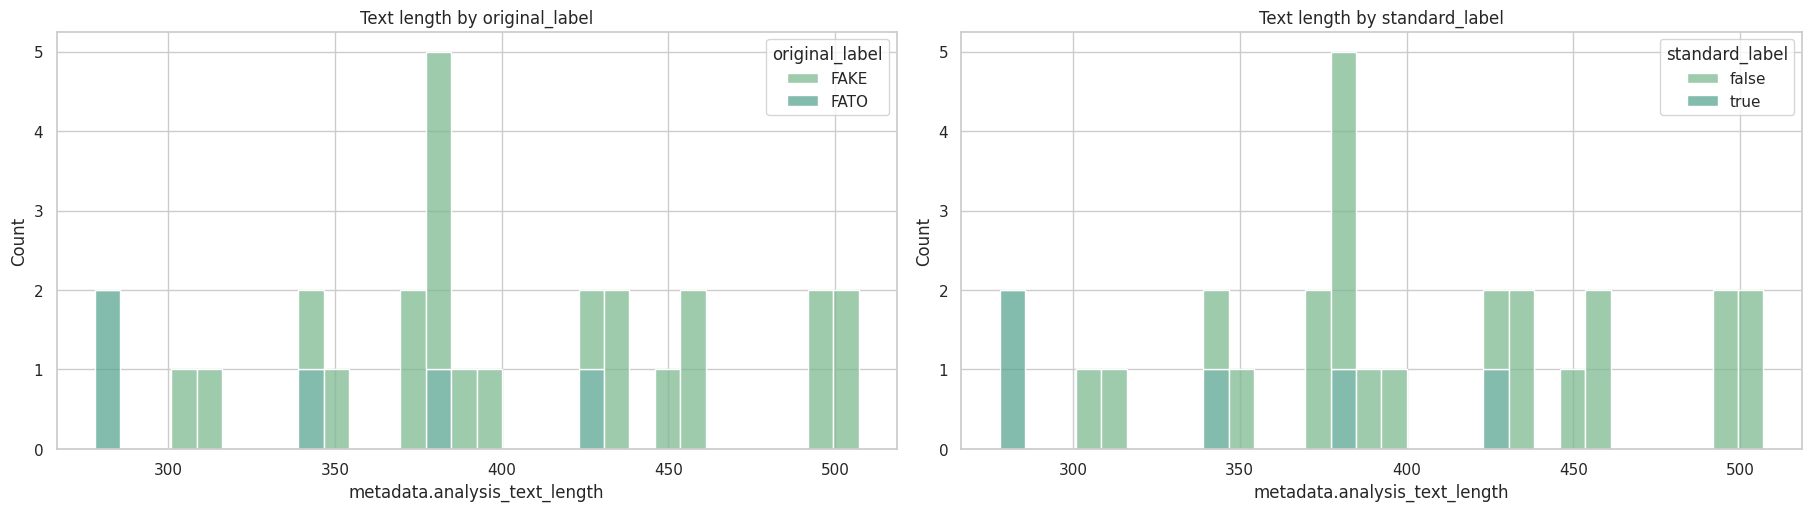

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,G1,27


,topic,count
0,G1,27
1,Fato ou Fake,27


,tag,count


/tmp/ipykernel_2047168/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
0,2025-10-01,4
1,2026-03-01,23


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,0
4,rating,0
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,c4f7de842ae80416592fb72f04611160784fe3c1efc3071bc4de3d2a74f77aee,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-que-video-mostre-barragem-de-santa-branca-no-interior-de-sp-se-rompendo-reservatorio-esta-bem-ab...,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-que-video-mostre-barragem-de-santa-branca-no-interior-de-sp-se-rompendo-reservatorio-esta-bem-ab...,"É #FAKE que vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite",2025-10-27T08:01:17.412-03:00,2026-03-15T02:50:32+00:00,"vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite","As imagens não representam um evento real; elas foram fabricadas com uso de inteligência artificial. A Light Energia, responsável pela gestão da barragem, a...",FAKE,FAKE,pt-BR,BR,"[G1, Fato ou Fake]",[],[],NewsArticle,20260315T010005Z-1d265f16,2025-10-27 11:01:17.412000+00:00,2026-03-15 02:50:32+00:00,3327.820719,121,109,265,g1.globo.com,1.0,"É #FAKE que vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite","vídeo mostre barragem de Santa Branca, no interior de SP, se rompendo; reservatório está bem abaixo do limite","As imagens não representam um evento real; elas foram fabricadas com uso de inteligência artificial. A Light Energia, responsável pela gestão da barragem, a...","é #fake que vídeo mostre barragem de santa branca, no interior de sp, se rompendo; reservatório está bem abaixo do limite vídeo mostre barragem de santa bra...",FAKE,false,2025-10-27T11:01:17.412000+00:00
1,d88581fc9b6d8b3463cdb72679954664d3b6da52f8019ab53e9ef5f85cd855ea,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-video-que-mostra-mulher-com-sapatos-voadores-em-exposicao.ghtml,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-video-que-mostra-mulher-com-sapatos-voadores-em-exposicao.ghtml,É #FAKE vídeo que mostra mulher com sapatos voadores em exposição,2025-10-27T18:44:50.441-03:00,2026-03-15T02:50:32+00:00,vídeo que mostra mulher com sapatos voadores em exposição,"As imagens, supostamente na China, não mostram um acontecimento real. O Fato ou Fake submeteu o vídeo ao detector de inteligência artificial Hive Moderation...",FAKE,FAKE,pt-BR,BR,"[G1, Fato ou Fake]",[],[],NewsArticle,20260315T010005Z-1d265f16,2025-10-27 21:44:50.441000+00:00,2026-03-15 02:50:32+00:00,3317.094878,65,57,260,g1.globo.com,1.0,É #FAKE vídeo que mostra mulher com sapatos voadores em exposição,vídeo que mostra mulher com sapatos voadores em exposição,"As imagens, supostamente na China, não mostram um acontecimento real. O Fato ou Fake submeteu o vídeo ao detector de inteligência artificial Hive Moderation...","é #fake vídeo que mostra mulher com sapatos voadores em exposição vídeo que mostra mulher com sapatos voadores em exposição as imagens, supostamente na chin...",FAKE,false,2025-10-27T21:44:50.441000+00:00
2,fa7834cad6038241b9a98c9a1ad581695490caefe27f759167664d027ee63036,g1_fato_ou_fake,G1 Fato ou Fake,g1_fato_ou_fake,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-foto-de-lula-abracando-capitao-hunter-cena-foi-criada-com-inteligencia-artificial.ghtml,https://g1.globo.com/fato-ou-fake/noticia/2025/10/27/e-fake-foto-de-lula-abracando-capitao-hunter-cena-foi-criada-com-inteligencia-artificial.ghtml,É #FAKE foto de Lula abraçando Capitão Hunter; cena foi criada com inteligência artificial,2025-10-27T08:01:16.026-03:00,2026-

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,de,193
1,o,176
2,em,84
3,ser,76
4,a,41
5,que,40
6,por,33
7,com,29
8,vídeo,27
9,e,27


,text,label,start_char,end_char
0,santa branca,LOC,37,49
0,sp,LOC,66,68
0,barragem de santa branca,LOC,135,159
0,sp,LOC,176,178
1,china,LOC,152,157
1,hive moderation,PER,265,280
2,lula,PER,16,20
2,capitão hunter,PER,31,45
2,lula,PER,99,103
2,capitão hunter,PER,114,128


,label,count
0,LOC,59
1,PER,31
2,ORG,17
3,MISC,8


,source_record_id,text_without_stopwords,lemmatized_text
0,c4f7de842ae80416592fb72f04611160784fe3c1efc3071bc4de3d2a74f77aee,fake vídeo mostre barragem santa branca interior sp rompendo reservatório abaixo limite vídeo mostre barragem santa branca interior sp rompendo reservatório...,ser fake que vídeo mostrar barragem de santa branco em o interior de sp se romper reservatório estar bem abaixo de o limite vídeo mostrar barragem de santa ...
1,d88581fc9b6d8b3463cdb72679954664d3b6da52f8019ab53e9ef5f85cd855ea,fake vídeo mostra mulher sapatos voadores exposição vídeo mostra mulher sapatos voadores exposição imagens supostamente china mostram acontecimento real fat...,ser fake vídeo que mostrar mulher com sapato voador em exposição vídeo que mostrar mulher com sapato voador em exposição o imagem supostamente em o china nã...
2,fa7834cad6038241b9a98c9a1ad581695490caefe27f759167664d027ee63036,fake foto lula abraçando capitão hunter cena criada inteligência artificial foto lula abraçando capitão hunter cena criada inteligência artificial ferrament...,ser fake fotor de lula abraçar capitão hunter cena ser criar com inteligência artificial foto de lula abraçar capitão hunter cena ser criar com inteligência...
3,1f8a407a260ef1cc2e87e51dd5885c035d5dbbae26d89ef6e5e79c3a27c06c8b,fake vídeo onda gigante atingindo litoral norte paulo imagens criadas ia vídeo onda gigante atingindo litoral norte paulo imagens criadas ia ferramenta dete...,ser fake vídeo de onda gigante atingir litoral norte de são paulo imagem ser criar com ir vídeo de onda gigante atingir litoral norte de são paulo imagem se...
4,5492928d012d8008321f94fce9fb0e946956885ad80cff3520ea2b70eb5174ce,fake vídeo mostre velório público khamenei cena exibe funeral chefe hezbollah 2025 vídeo mostre velório público khamenei cena exibe funeral chefe hezbollah ...,ser fake que vídeo mostrar velório público de ali khamenei cena exibir funeral de chefe de o hezbollah em 2025 vídeo mostrar velório público de ali khamenei...
5,8dd63ea9576ce0bd108b13e167693fd975cceda9b0d21f51f5670489cbd8a925,fake vídeo mostre bronca trump premiê espanhol traição guerra irã cena ocorreu 2019 vídeo mostre bronca trump premiê espanhol traição guerra irã cena ocorre...,ser fake que vídeo mostrar bronca de trump em premiê espanhol por traição em o guerra contra o irã cena ocorrer em 2019 vídeo mostrar bronca de trump em pre...
6,f094bf37360eb702de49aacc95e706ce2404d80a94a26c389af1abe4c34ad2f8,fato vídeo mostra depósito petróleo teerã tomado chamas ataque israel vídeo mostra depósito petróleo teerã tomado chamas ataque israel ações forças israelen...,ser fato vídeo mostrar depósito de petróleo em teerã tomar por chama após ataque de israel vídeo mostrar depósito de petróleo em teerã tomar por chama após ...
7,86696d14aadb9742d87daddd678e5319e8778ac5f0f293771414100e0bd7db15,fake andré mendonça acionar lei autorizando cia investigações prisões brasil andré mendonça acionar lei autorizando cia investigações prisões brasil mecanis...,ser fake que andré mendonça poder acionar lei autorizar cia a fazer investigação e prisão em o brasil andré mendonça poder acionar lei autorizar cia a fazer...
8,2e68039d0ad8dc191499fad00088329f05a57277a5501a4bd4b0bbf6fb29e66c,fake trump tenha suspendido entrada brasileiros lula cancelar visto assessor americano trump tenha suspendido entrada brasileiros lula cancelar visto assess...,ser fake que trump ter suspender o entrada de brasileiro após lula cancelar ver de assessor americano trump ter suspender o entrada de brasileiro após lula ...
9,74d9aea79e7c0b5b33d4aa1f5159461dde27e05fa7188724c078ae1243eb9ead,fake governo lula propôs taxar entregadores aplicativo r$ 10 corrida governo lula propôs taxar entregadores aplicativo r$ 10 corrida proposta apresentada de...,ser fake que governo lula propor taxar entregador de aplicativo em r$ 10 por corrida governo lula propor taxar entregador de aplicativo em r$ 10 por corrida...


## Export processed JSONL

In [10]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T232024Z-g1_fato_ou_fake,27,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232024Z-g1_fato_ou_fake/spiders/g1_fato_ou_fake.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232024Z-g1_fato_ou_fake/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232024Z-g1_fato_ou_fake/manifest.json
